### Transformer VS GPT-1 차이점 정리 및 구현 단계 요약

- Transformer block : Encoder-Decoder가 아닌 Decoder 단일으로 구성하므로 cross attention은 필요하지 않음 -> (causal)masked multi head self attention만 구현 
- learned weight Wp : 기존 transformer에서는 PE로 위치만 넣는데 GPT-1에서는 위치까지 학습할 대상으로 만듦 
- Task-specific input transformation(전처리 단계) : 함수만 구현(데이터셋 한계)
- 모델 크기 : 논문에서는 12층을 썼으나 데이터도 크지 않고 하드웨어 한계 - 4개정도 쌓아보는걸로 

In [1]:
import os
import math
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sentencepiece as spm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary

from sklearn.model_selection import train_test_split




SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


### 1. 데이터 불러오기

챗봇 데이터는 질문 `Q`와 답변 `A`가 쌍으로 들어 있는 데이터 -> encoder-decoder 구조에서는 질문과 답변을 서로 다른 입력으로 나누었지만 여기서는 하나의 시퀀스로 이어붙임


In [2]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'quest.ipynb').exists() and (PROJECT_DIR / 'Ex09').exists():
    PROJECT_DIR = PROJECT_DIR / 'Ex09'
elif PROJECT_DIR.name != 'Ex09' and (PROJECT_DIR / 'Ex09' / 'quest.ipynb').exists():
    PROJECT_DIR = PROJECT_DIR / 'Ex09'

data_path = Path.home() / 'data/songys_chatbot/ChatbotData.csv'
chatbot_df = pd.read_csv(data_path)

print('PROJECT_DIR:', PROJECT_DIR)
print('데이터 경로:', data_path)
print('데이터 크기:', chatbot_df.shape)
print('컬럼:', chatbot_df.columns.tolist())
display(chatbot_df.head())


PROJECT_DIR: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex09
데이터 경로: /home/thkim0/data/songys_chatbot/ChatbotData.csv
데이터 크기: (11823, 3)
컬럼: ['Q', 'A', 'label']


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [3]:
label_names = {
    0: 'daily',
    1: 'breakup_negative',
    2: 'love_positive',
}

label_counts = (
    chatbot_df['label']
    .value_counts()
    .sort_index()
    .rename_axis('label')
    .reset_index(name='count')
)
label_counts['label_name'] = label_counts['label'].map(label_names)
label_counts['ratio'] = label_counts['count'] / len(chatbot_df)

print('결측치 개수')
display(chatbot_df.isna().sum().to_frame('missing_count'))

print('레이블 분포')
display(label_counts[['label', 'label_name', 'count', 'ratio']])


결측치 개수


,missing_count
Q,0
A,0
label,0


레이블 분포


,label,label_name,count,ratio
0,0,daily,5290,0.447433
1,1,breakup_negative,3570,0.301954
2,2,love_positive,2963,0.250613


### 2. Preprocessing&Split

`label`은 생성 모델의 입력으로 직접 쓰지 않고, train/validation 분포를 유지하기 위한 stratified split에만 사용


In [4]:
def preprocess_sentence(sentence):
    if pd.isna(sentence):
        return ''

    sentence = unicodedata.normalize('NFC', str(sentence))
    sentence = re.sub(r'([?.!,])', r' \1 ', sentence)
    sentence = re.sub(r'[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,]+', ' ', sentence)
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    return sentence


df_clean = chatbot_df.copy()
df_clean['Q_clean'] = df_clean['Q'].map(preprocess_sentence)
df_clean['A_clean'] = df_clean['A'].map(preprocess_sentence)

before_count = len(df_clean)
df_clean = df_clean[(df_clean['Q_clean'] != '') & (df_clean['A_clean'] != '')].copy()
df_clean = df_clean.reset_index(drop=True)
after_count = len(df_clean)

print(f'전처리 전 샘플 수: {before_count}')
print(f'전처리 후 샘플 수: {after_count}')
print(f'제거된 샘플 수: {before_count - after_count}')
display(df_clean[['Q', 'Q_clean', 'A', 'A_clean', 'label']].head(10))


전처리 전 샘플 수: 11823
전처리 후 샘플 수: 11823
제거된 샘플 수: 0


,Q,Q_clean,A,A_clean,label
0,12시 땡!,12시 땡 !,하루가 또 가네요.,하루가 또 가네요 .,0
1,1지망 학교 떨어졌어,1지망 학교 떨어졌어,위로해 드립니다.,위로해 드립니다 .,0
2,3박4일 놀러가고 싶다,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,여행은 언제나 좋죠 .,0
3,3박4일 정도 놀러가고 싶다,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,여행은 언제나 좋죠 .,0
4,PPL 심하네,PPL 심하네,눈살이 찌푸려지죠.,눈살이 찌푸려지죠 .,0
5,SD카드 망가졌어,SD카드 망가졌어,다시 새로 사는 게 마음 편해요.,다시 새로 사는 게 마음 편해요 .,0
6,SD카드 안돼,SD카드 안돼,다시 새로 사는 게 마음 편해요.,다시 새로 사는 게 마음 편해요 .,0
7,SNS 맞팔 왜 안하지ㅠㅠ,SNS 맞팔 왜 안하지ㅠㅠ,잘 모르고 있을 수도 있어요.,잘 모르고 있을 수도 있어요 .,0
8,SNS 시간낭비인 거 아는데 매일 하는 중,SNS 시간낭비인 거 아는데 매일 하는 중,시간을 정하고 해보세요.,시간을 정하고 해보세요 .,0
9,SNS 시간낭비인데 자꾸 보게됨,SNS 시간낭비인데 자꾸 보게됨,시간을 정하고 해보세요.,시간을 정하고 해보세요 .,0


In [5]:
train_df, val_df = train_test_split(
    df_clean,
    test_size=0.1,
    random_state=SEED,
    stratify=df_clean['label'],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)


def label_ratio_table(df, split_name):
    table = (
        df['label']
        .value_counts(normalize=True)
        .sort_index()
        .rename_axis('label')
        .reset_index(name='ratio')
    )
    table['label_name'] = table['label'].map(label_names)
    table['count'] = df['label'].value_counts().sort_index().values
    table['split'] = split_name
    return table[['split', 'label', 'label_name', 'count', 'ratio']]


split_ratio = pd.concat([
    label_ratio_table(df_clean, 'all'),
    label_ratio_table(train_df, 'train'),
    label_ratio_table(val_df, 'validation'),
], ignore_index=True)

print(f'전체 데이터 수: {len(df_clean)}')
print(f'train 데이터 수: {len(train_df)}')
print(f'validation 데이터 수: {len(val_df)}')
display(split_ratio)


전체 데이터 수: 11823
train 데이터 수: 10640
validation 데이터 수: 1183


,split,label,label_name,count,ratio
0,all,0,daily,5290,0.447433
1,all,1,breakup_negative,3570,0.301954
2,all,2,love_positive,2963,0.250613
3,train,0,daily,4761,0.447462
4,train,1,breakup_negative,3213,0.301974
5,train,2,love_positive,2666,0.250564
6,validation,0,daily,529,0.447168
7,validation,1,breakup_negative,357,0.301775
8,validation,2,love_positive,297,0.251057


### 3. Tokenizer - SP Unigram



 `<sep>`: 질문과 답변의 경계 delimiter -> 토큰화 과정에서 쪼개지 않도록 `user_defined_symbols`에 등록


In [6]:
VOCAB_SIZE = 4000
TOKENIZER_PREFIX = PROJECT_DIR / 'spm_korean_chatbot_gpt_unigram'
TOKENIZER_MODEL_PATH = TOKENIZER_PREFIX.with_suffix('.model')
TOKENIZER_VOCAB_PATH = TOKENIZER_PREFIX.with_suffix('.vocab')
TOKENIZER_CORPUS_PATH = PROJECT_DIR / 'spm_korean_chatbot_gpt_unigram_train_corpus.txt'

SPECIAL_SYMBOLS = ['<sep>', '<extract>', '<delim>']

if not TOKENIZER_MODEL_PATH.exists():
    with open(TOKENIZER_CORPUS_PATH, 'w', encoding='utf-8') as f:
        for question, answer in train_df[['Q_clean', 'A_clean']].itertuples(index=False):
            f.write(f'<bos> {question} <sep> {answer} <eos>\n')
            f.write(question + '\n')
            f.write(answer + '\n')

    spm.SentencePieceTrainer.Train(
        input=str(TOKENIZER_CORPUS_PATH),
        model_prefix=str(TOKENIZER_PREFIX),
        vocab_size=VOCAB_SIZE,
        character_coverage=1.0,
        model_type='unigram',
        pad_id=0,
        bos_id=1,
        eos_id=2,
        unk_id=3,
        pad_piece='<pad>',
        bos_piece='<bos>',
        eos_piece='<eos>',
        unk_piece='<unk>',
        user_defined_symbols=','.join(SPECIAL_SYMBOLS),
        hard_vocab_limit=False,
    )
    print('SentencePiece unigram 모델 학습 완료:', TOKENIZER_MODEL_PATH)
else:
    print('기존 SentencePiece unigram 모델 로드:', TOKENIZER_MODEL_PATH)

sp = spm.SentencePieceProcessor()
sp.Load(str(TOKENIZER_MODEL_PATH))

PAD_ID = sp.pad_id()
BOS_ID = sp.bos_id()
EOS_ID = sp.eos_id()
UNK_ID = sp.unk_id()
SEP_ID = sp.piece_to_id('<sep>')
EXTRACT_ID = sp.piece_to_id('<extract>')
DELIM_ID = sp.piece_to_id('<delim>')

print('PAD_ID, BOS_ID, EOS_ID, UNK_ID:', PAD_ID, BOS_ID, EOS_ID, UNK_ID)
print('SEP_ID, EXTRACT_ID, DELIM_ID:', SEP_ID, EXTRACT_ID, DELIM_ID)
print('vocab size:', sp.GetPieceSize())
print('special pieces:', [sp.id_to_piece(i) for i in [PAD_ID, BOS_ID, EOS_ID, UNK_ID, SEP_ID, EXTRACT_ID, DELIM_ID]])


기존 SentencePiece unigram 모델 로드: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex09/spm_korean_chatbot_gpt_unigram.model
PAD_ID, BOS_ID, EOS_ID, UNK_ID: 0 1 2 3
SEP_ID, EXTRACT_ID, DELIM_ID: 4 5 6
vocab size: 4000
special pieces: ['<pad>', '<bos>', '<eos>', '<unk>', '<sep>', '<extract>', '<delim>']


### 4. GPT-Style Sequence 변환



`sequence: <bos> Q <sep> A <eos>`

이전 token들을 보고 다음 token을 예측해야 하므로, 학습 입력과 target은 한칸씩 밀림

`input:  <bos> Q <sep> A`

`target: Q <sep> A <eos>`


In [7]:
def encode_text(text):
    return sp.encode_as_ids(preprocess_sentence(text))


def ids_to_pieces(ids):
    return [sp.id_to_piece(int(token_id)) for token_id in ids]


def build_gpt_sequence(question, answer):
    question_ids = encode_text(question)
    answer_ids = encode_text(answer)
    return [BOS_ID] + question_ids + [SEP_ID] + answer_ids + [EOS_ID]


sample_row = train_df.iloc[0]
sample_sequence_ids = build_gpt_sequence(sample_row['Q_clean'], sample_row['A_clean'])
sample_input_ids = sample_sequence_ids[:-1]
sample_target_ids = sample_sequence_ids[1:]

print('변환 전 Q:', sample_row['Q'])
print('변환 전 A:', sample_row['A'])
print('\n전처리 후 Q:', sample_row['Q_clean'])
print('전처리 후 A:', sample_row['A_clean'])
print('\nsequence pieces:')
print(ids_to_pieces(sample_sequence_ids))
print('\ninput pieces:')
print(ids_to_pieces(sample_input_ids))
print('\ntarget pieces:')
print(ids_to_pieces(sample_target_ids))


변환 전 Q: 헤어진지 25일째
변환 전 A: 헤어진 하루를 헤아리는 거처럼 힘든 일은 없을 거예요.

전처리 후 Q: 헤어진지 25일째
전처리 후 A: 헤어진 하루를 헤아리는 거처럼 힘든 일은 없을 거예요 .

sequence pieces:
['<bos>', '▁헤어진지', '▁2', '5', '일째', '<sep>', '▁헤어진', '▁하루', '를', '▁헤아리', '는', '▁거', '처럼', '▁힘든', '▁일', '은', '▁없을', '▁거예요', '▁.', '<eos>']

input pieces:
['<bos>', '▁헤어진지', '▁2', '5', '일째', '<sep>', '▁헤어진', '▁하루', '를', '▁헤아리', '는', '▁거', '처럼', '▁힘든', '▁일', '은', '▁없을', '▁거예요', '▁.']

target pieces:
['▁헤어진지', '▁2', '5', '일째', '<sep>', '▁헤어진', '▁하루', '를', '▁헤아리', '는', '▁거', '처럼', '▁힘든', '▁일', '은', '▁없을', '▁거예요', '▁.', '<eos>']


### 5. Dataset loading & Padding

batch마다 문장 길이가 다르므로 `pad_sequence`로 batch 내부에서만 padding합니다. padding 위치는 attention에서도 가리고, loss 계산에서도 제외


In [8]:
class GPTChatbotDataset(Dataset):
    def __init__(self, dataframe):
        self.questions = dataframe['Q_clean'].tolist()
        self.answers = dataframe['A_clean'].tolist()

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        sequence_ids = build_gpt_sequence(self.questions[idx], self.answers[idx])
        input_ids = sequence_ids[:-1]
        target_ids = sequence_ids[1:]
        return (
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(target_ids, dtype=torch.long),
        )


def gpt_collate_fn(batch):
    input_ids, target_ids = zip(*batch)
    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=PAD_ID)
    target_ids = pad_sequence(target_ids, batch_first=True, padding_value=PAD_ID)
    return input_ids, target_ids


BATCH_SIZE = 32
pin_memory = torch.cuda.is_available()

train_dataset = GPTChatbotDataset(train_df)
val_dataset = GPTChatbotDataset(val_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=gpt_collate_fn,
    num_workers=0,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=gpt_collate_fn,
    num_workers=0,
    pin_memory=pin_memory,
)

for batch_input_ids, batch_target_ids in train_loader:
    print('input_ids.shape:', batch_input_ids.shape)
    print('target_ids.shape:', batch_target_ids.shape)
    print('logits 목표 shape: (batch_size, seq_len, vocab_size)')
    break


input_ids.shape: torch.Size([32, 28])
target_ids.shape: torch.Size([32, 28])
logits 목표 shape: (batch_size, seq_len, vocab_size)


### 6. Causal Mask 적용 확인


In [9]:
def create_padding_mask(x, pad_id=PAD_ID):
    mask = (x == pad_id).float()
    return mask.unsqueeze(1).unsqueeze(2)


def create_causal_padding_mask(x, pad_id=PAD_ID):
    seq_len = x.size(1)
    causal_mask = torch.triu(
        torch.ones((seq_len, seq_len), device=x.device),
        diagonal=1,
    )
    causal_mask = causal_mask.unsqueeze(0).unsqueeze(1)
    padding_mask = create_padding_mask(x, pad_id=pad_id)
    return torch.maximum(causal_mask, padding_mask)


def show_visible_attention_area(seq_len=4):
    dummy = torch.ones((1, seq_len), dtype=torch.long)
    mask = create_causal_padding_mask(dummy, pad_id=PAD_ID)[0, 0]
    visible = (mask == 0).int()
    return visible


print('attention 가능 영역: 1=볼 수 있음, 0=미래라 볼 수 없음')
print(show_visible_attention_area(seq_len=4))

print('\n실제 mask convention: 1=가림, 0=허용')
print(create_causal_padding_mask(torch.ones((1, 4), dtype=torch.long), pad_id=PAD_ID)[0, 0])


attention 가능 영역: 1=볼 수 있음, 0=미래라 볼 수 없음
tensor([[1, 0, 0, 0],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 1]], dtype=torch.int32)

실제 mask convention: 1=가림, 0=허용
tensor([[0., 1., 1., 1.],
        [0., 0., 1., 1.],
        [0., 0., 0., 1.],
        [0., 0., 0., 0.]])


### 7. Decoder-only 모델 구현



`input_ids: (batch, seq_len)`

`embedding + positional encoding: (batch, seq_len, d_model)`

`GPT block output: (batch, seq_len, d_model)`

`final logits: (batch, seq_len, vocab_size)`

`PE : 기존 유지`


In [10]:
class LearnedPositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super().__init__()
        self.position = position
        self.d_model = d_model
        self.position_embedding = nn.Embedding(position, d_model)

    def forward(self, x):
        seq_len = x.size(1)
        if seq_len > self.position:
            raise ValueError(
                f'sequence length {seq_len} exceeds learned position embedding length {self.position}'
            )

        position_ids = torch.arange(seq_len, device=x.device).unsqueeze(0)
        return x + self.position_embedding(position_ids)


def scaled_dot_product_attention(query, key, value, mask=None):
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))
    logits = matmul_qk / math.sqrt(key.size(-1))

    if mask is not None:
        logits = logits + (mask * -1e9)

    attention_weights = F.softmax(logits, dim=-1)
    output = torch.matmul(attention_weights, value)
    return output, attention_weights


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        if d_model % num_heads != 0:
            raise ValueError('d_model must be divisible by num_heads')

        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)
        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)

        query = self.split_heads(self.query_dense(query), batch_size)
        key = self.split_heads(self.key_dense(key), batch_size)
        value = self.split_heads(self.value_dense(value), batch_size)

        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)
        return self.out_dense(concat_attention)


class GPTDecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, dff, dropout=0.1):
        super().__init__()
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, dff),
            nn.GELU(),
            nn.Linear(dff, d_model),
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # x와 self_attn_output의 shape은 모두 (batch, seq_len, d_model)이므로 residual add가 가능하다.
        self_attn_output = self.self_mha(x, x, x, mask=mask)
        self_attn_output = self.dropout1(self_attn_output)
        out1 = self.norm1(x + self_attn_output)

        # feed-forward output도 (batch, seq_len, d_model)이므로 residual add가 가능하다.
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        return self.norm2(out1 + ffn_output)


class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size, num_layers, d_model, num_heads, dff, max_position, dropout=0.1, pad_id=PAD_ID):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model
        self.max_position = max_position

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_encoding = LearnedPositionalEncoding(max_position, d_model)
        self.dropout = nn.Dropout(dropout)
        self.decoder_blocks = nn.ModuleList([
            GPTDecoderBlock(d_model, num_heads, dff, dropout)
            for _ in range(num_layers)
        ])
        self.final_linear = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids):
        mask = create_causal_padding_mask(input_ids, pad_id=self.pad_id)

        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        for block in self.decoder_blocks:
            x = block(x, mask=mask)

        return self.final_linear(x)


In [11]:
NUM_LAYERS = 4
D_MODEL = 128
NUM_HEADS = 4
DFF = 512
DROPOUT = 0.1
EPOCHS = 30
WARMUP_STEPS = 1000
PATIENCE = 5
MIN_DELTA = 1e-4
MAX_NEW_TOKENS = 40
VOCAB_SIZE = sp.GetPieceSize()
max_train_position = max(len(input_ids) for input_ids, _ in train_dataset)
max_val_position = max(len(input_ids) for input_ids, _ in val_dataset)
MAX_POSITION = max(max_train_position, max_val_position, 128)


model = GPTLanguageModel(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dff=DFF,
    max_position=MAX_POSITION,
    dropout=DROPOUT,
    pad_id=PAD_ID,
).to(device)

print('model parameters:', sum(p.numel() for p in model.parameters()))
print('VOCAB_SIZE:', VOCAB_SIZE)
print('MAX_POSITION:', MAX_POSITION)


summary(model)


model parameters: 1837472
VOCAB_SIZE: 4000
MAX_POSITION: 128


Layer (type:depth-idx)                   Param #
GPTLanguageModel                         --
├─Embedding: 1-1                         512,000
├─LearnedPositionalEncoding: 1-2         --
│    └─Embedding: 2-1                    16,384
├─Dropout: 1-3                           --
├─ModuleList: 1-4                        --
│    └─GPTDecoderBlock: 2-2              --
│    │    └─MultiHeadAttention: 3-1      66,048
│    │    └─Dropout: 3-2                 --
│    │    └─LayerNorm: 3-3               256
│    │    └─Sequential: 3-4              131,712
│    │    └─Dropout: 3-5                 --
│    │    └─LayerNorm: 3-6               256
│    └─GPTDecoderBlock: 2-3              --
│    │    └─MultiHeadAttention: 3-7      66,048
│    │    └─Dropout: 3-8                 --
│    │    └─LayerNorm: 3-9               256
│    │    └─Sequential: 3-10             131,712
│    │    └─Dropout: 3-11                --
│    │    └─LayerNorm: 3-12              256
│    └─GPTDecoderBlock: 2-4             

### 8. 학습 


In [12]:
def get_lr_lambda(d_model, warmup_steps=1000):
    d_model = float(d_model)

    def lr_lambda(step):
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))

    return lr_lambda


loss_function = nn.CrossEntropyLoss(ignore_index=PAD_ID, reduction='sum')
optimizer = optim.Adam(model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=WARMUP_STEPS),
)


def count_correct_tokens(logits, target, pad_id=PAD_ID):
    preds = logits.argmax(dim=-1)
    mask = target != pad_id
    correct = ((preds == target) & mask).sum().item()
    total = mask.sum().item()
    return correct, total


def train_step(model, batch, optimizer, scheduler, loss_function, device):
    model.train()
    input_ids, target_ids = [x.to(device) for x in batch]

    optimizer.zero_grad()
    logits = model(input_ids)
    loss_sum = loss_function(logits.reshape(-1, logits.size(-1)), target_ids.reshape(-1))
    token_count = (target_ids != PAD_ID).sum().clamp(min=1)
    loss = loss_sum / token_count

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    correct, total = count_correct_tokens(logits, target_ids, pad_id=PAD_ID)
    return loss_sum.item(), correct, total


def evaluate(model, data_loader, loss_function, device):
    model.eval()
    total_loss_sum = 0.0
    total_correct = 0
    total_tokens = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids, target_ids = [x.to(device) for x in batch]
            logits = model(input_ids)
            loss_sum = loss_function(logits.reshape(-1, logits.size(-1)), target_ids.reshape(-1))
            correct, token_count = count_correct_tokens(logits, target_ids, pad_id=PAD_ID)

            total_loss_sum += loss_sum.item()
            total_correct += correct
            total_tokens += token_count

    avg_loss = total_loss_sum / max(total_tokens, 1)
    avg_acc = total_correct / max(total_tokens, 1)
    return avg_loss, avg_acc


In [13]:
HISTORY_DIR = PROJECT_DIR / 'histories'
HISTORY_PATH = HISTORY_DIR / 'history_transformer_korean_chatbot_gpt_unigram_wp.csv'
CHECKPOINT_PATH = HISTORY_DIR / 'transformer_korean_chatbot_gpt_unigram_wp_best.pt'


def checkpoint_config():
    return {
        'architecture': 'gpt_style_decoder_only_lm_learned_wp',
        'tokenizer_type': 'sentencepiece_unigram',
        'num_layers': NUM_LAYERS,
        'd_model': D_MODEL,
        'num_heads': NUM_HEADS,
        'dff': DFF,
        'dropout': DROPOUT,
        'vocab_size': VOCAB_SIZE,
        'max_position': MAX_POSITION,
        'max_new_tokens': MAX_NEW_TOKENS,
        'warmup_steps': WARMUP_STEPS,
        'pad_id': PAD_ID,
        'bos_id': BOS_ID,
        'eos_id': EOS_ID,
        'unk_id': UNK_ID,
        'sep_id': SEP_ID,
    }


def train_model(model, train_loader, val_loader, optimizer, scheduler, loss_function, epochs, patience, min_delta, device):
    HISTORY_DIR.mkdir(parents=True, exist_ok=True)

    history = []
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss_sum = 0.0
        train_correct = 0
        train_tokens = 0

        for step, batch in enumerate(train_loader, start=1):
            loss_sum, correct, token_count = train_step(
                model, batch, optimizer, scheduler, loss_function, device
            )
            train_loss_sum += loss_sum
            train_correct += correct
            train_tokens += token_count

            if step % 100 == 0:
                print(
                    f'  Step {step:04d} | '
                    f'Loss: {train_loss_sum / max(train_tokens, 1):.4f} | '
                    f'Acc: {train_correct / max(train_tokens, 1):.4f} | '
                    f'LR: {scheduler.get_last_lr()[0]:.8f}'
                )

        train_loss = train_loss_sum / max(train_tokens, 1)
        train_acc = train_correct / max(train_tokens, 1)
        val_loss, val_acc = evaluate(model, val_loader, loss_function, device)

        is_best = val_loss < best_val_loss - min_delta
        if is_best:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(
                {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'best_val_loss': best_val_loss,
                    'config': checkpoint_config(),
                },
                CHECKPOINT_PATH,
            )
        else:
            patience_counter += 1

        row = {
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'learning_rate': scheduler.get_last_lr()[0],
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
            'is_best': is_best,
        }
        history.append(row)
        history_df = pd.DataFrame(history)
        history_df.to_csv(HISTORY_PATH, index=False)

        print(
            f'Epoch {epoch:02d}/{epochs} | '
            f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
            f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | '
            f'LR: {scheduler.get_last_lr()[0]:.8f}'
        )

        if is_best:
            print(f'  -> Best checkpoint saved: {CHECKPOINT_PATH}')
        else:
            print(f'  -> EarlyStopping counter: {patience_counter}/{patience}')

        if patience_counter >= patience:
            print(f'Early stopping triggered at epoch {epoch}')
            break

    if CHECKPOINT_PATH.exists():
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(device)
        print('Best checkpoint loaded:', CHECKPOINT_PATH)

    print('History saved:', HISTORY_PATH)
    return pd.DataFrame(history)


def plot_loss_history(history_df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train Loss')
    axes[0].plot(history_df['epoch'], history_df['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(history_df['epoch'], history_df['train_acc'], label='Train Accuracy')
    axes[1].plot(history_df['epoch'], history_df['val_acc'], label='Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


  Step 0100 | Loss: 7.4303 | Acc: 0.1154 | LR: 0.00028230
  Step 0200 | Loss: 6.6324 | Acc: 0.1608 | LR: 0.00056181
  Step 0300 | Loss: 6.2155 | Acc: 0.1873 | LR: 0.00084132
Epoch 01/30 | Train Loss: 6.1132 | Train Acc: 0.1939 | Val Loss: 5.0890 | Val Acc: 0.2599 | LR: 0.00093356
  -> Best checkpoint saved: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex09/histories/transformer_korean_chatbot_gpt_unigram_wp_best.pt
  Step 0100 | Loss: 4.9694 | Acc: 0.2679 | LR: 0.00121307
  Step 0200 | Loss: 4.8902 | Acc: 0.2737 | LR: 0.00149258
  Step 0300 | Loss: 4.8170 | Acc: 0.2792 | LR: 0.00177208
Epoch 02/30 | Train Loss: 4.7963 | Train Acc: 0.2804 | Val Loss: 4.5078 | Val Acc: 0.2985 | LR: 0.00186432
  -> Best checkpoint saved: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex09/histories/transformer_korean_chatbot_gpt_unigram_wp_best.pt
  Step 0100 | Loss: 4.3597 | Acc: 0.3024 | LR: 0.00214383
  Step 0200 | Loss: 4.3392 | Acc: 0.3054 | LR: 0.00242334
  Step 0300 | Loss: 4.3200 | Acc: 0.3074

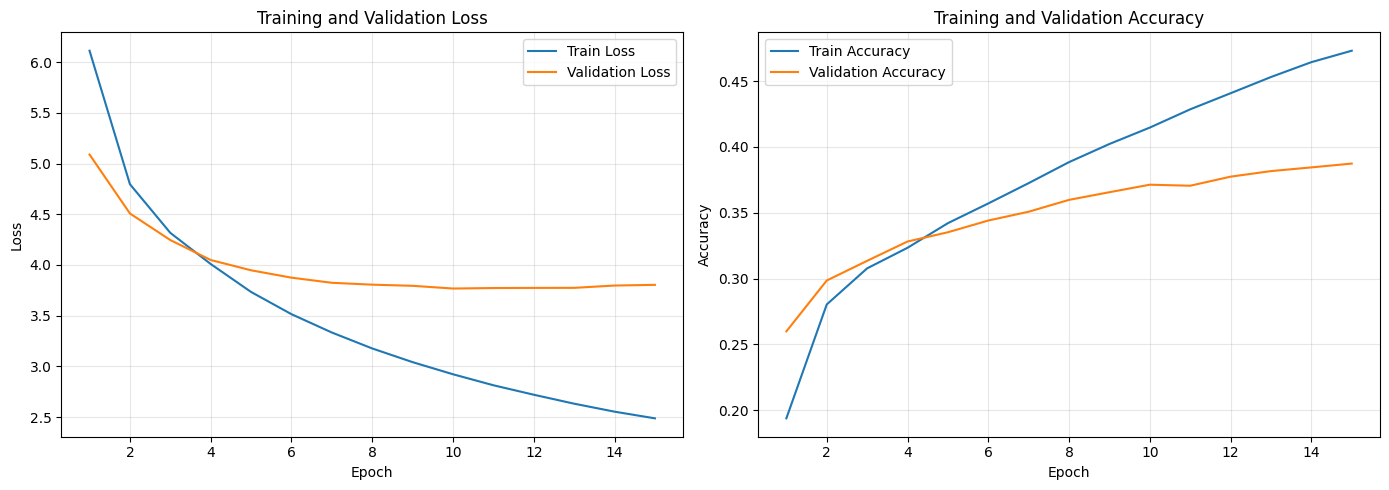

In [14]:
# 실행 코드 
history_df = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    loss_function,
    epochs=EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    device=device,
)
plot_loss_history(history_df)


### 9. Autoregressive Generation

생성 단계에서는 `<bos> 질문 <sep>`까지를 prompt로 넣고 마지막 위치의 logits에서 다음 token을 하나 선택 ->  
선택된 token은 다시 입력 뒤에 붙고, 이 과정을 `<eos>`가 나오거나 최대 길이에 도달할 때까지 반복


In [15]:
def load_best_checkpoint_if_exists(model, checkpoint_path=CHECKPOINT_PATH, device=device):
    if checkpoint_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(device)
        model.eval()
        print('Best checkpoint loaded:', checkpoint_path)
    else:
        print('Best checkpoint가 아직 없습니다. 학습 후 다시 실행하세요.')
    return model


def decode_generated_ids(ids):
    special_ids = {PAD_ID, BOS_ID, SEP_ID, EXTRACT_ID, DELIM_ID}
    clean_ids = [int(token_id) for token_id in ids if int(token_id) not in special_ids]
    return sp.decode_ids(clean_ids).strip()


def sample_next_token(logits, temperature=1.0, forbidden_ids=None):
    logits = logits.detach().clone()
    forbidden_ids = forbidden_ids or []
    for token_id in forbidden_ids:
        if 0 <= int(token_id) < logits.size(-1):
            logits[int(token_id)] = -float('inf')

    if temperature is None or temperature <= 0:
        return int(torch.argmax(logits).item())

    logits = logits / temperature
    probs = torch.softmax(logits, dim=-1)
    if not torch.isfinite(probs).all() or probs.sum().item() <= 0:
        return int(torch.argmax(logits).item())
    return int(torch.multinomial(probs, num_samples=1).item())

def generate_text(prompt, max_new_tokens=MAX_NEW_TOKENS, temperature=1.0):
    model.eval()
    prompt_ids = [BOS_ID] + encode_text(prompt)
    generated_ids = list(prompt_ids)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            model_input_ids = generated_ids[-model.max_position:]
            input_tensor = torch.tensor([model_input_ids], dtype=torch.long, device=device)

            logits = model(input_tensor)
            next_logits = logits[0, -1, :]

            next_id = sample_next_token(
                next_logits,
                temperature=temperature,
                forbidden_ids=[PAD_ID, BOS_ID, SEP_ID],  # 문장 이어쓰기에서는 sep 금지
            )

            if next_id == EOS_ID:
                break

            generated_ids.append(next_id)

    return decode_generated_ids(generated_ids[len(prompt_ids):])


def generate_reply(question, max_new_tokens=MAX_NEW_TOKENS, temperature=0.8):
    model.eval()
    question_ids = encode_text(question)
    prompt_ids = [BOS_ID] + question_ids + [SEP_ID]
    generated_ids = list(prompt_ids)
    answer_ids = []

    with torch.no_grad():
        for _ in range(max_new_tokens):
            model_input_ids = generated_ids[-model.max_position:]
            input_tensor = torch.tensor([model_input_ids], dtype=torch.long, device=device)
            logits = model(input_tensor)
            next_logits = logits[0, -1, :]
            next_id = sample_next_token(
                next_logits,
                temperature=temperature,
                forbidden_ids=[PAD_ID, BOS_ID, SEP_ID],
            )

            if next_id == EOS_ID:
                break

            generated_ids.append(next_id)
            answer_ids.append(next_id)

    return decode_generated_ids(answer_ids)


In [16]:
demo_questions = [
    '업무가 너무 많아',
    '오늘 기분이 안 좋아',
    '친구랑 싸웠어',
    '너무 피곤해',
    '내일 시험이야',
]

model = load_best_checkpoint_if_exists(model)
for question in demo_questions:
    print('Q:', question)
    print('A:', generate_reply(question, max_new_tokens=MAX_NEW_TOKENS, temperature=0.0))
    print('-' * 50)


Best checkpoint loaded: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex09/histories/transformer_korean_chatbot_gpt_unigram_wp_best.pt
Q: 업무가 너무 많아
A: 한 번씩 할 수 있을 거예요 .
--------------------------------------------------
Q: 오늘 기분이 안 좋아
A: 네 말씀해주세요 .
--------------------------------------------------
Q: 친구랑 싸웠어
A: 네 말씀해주세요 .
--------------------------------------------------
Q: 너무 피곤해
A: 많이 생각하지 말고 풀렸죠 .
--------------------------------------------------
Q: 내일 시험이야
A: 식물을 해보세요 .
--------------------------------------------------


In [22]:

model = load_best_checkpoint_if_exists(model)
while True:
    question = input('질문을 입력하세요. 종료하려면 q 입력: ')

    if question.lower() in ['q', 'quit', 'exit']:
        print('종료합니다.')
        break

    answer = generate_reply(
        question,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=0.6,
    )

    print(f'{question}: {answer}')
    print('-' * 50)


Best checkpoint loaded: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex09/histories/transformer_korean_chatbot_gpt_unigram_wp_best.pt


여자친구가 화났어: 대화를 풀어보세요 .
--------------------------------------------------
배고파 죽겠어: 식에 가서 쉬고 오세요 .
--------------------------------------------------
요즘 너무 피곤해: 가슴 아픈 만큼 행복해지세요 .
--------------------------------------------------
나는누구 여긴어디: 저도 받고 싶어요 .
--------------------------------------------------
리만 제타 함수 ζ(s)의 모든 비자명한 영점의 실수부는 1/2일까?: 괜찮지만 자신을거라 생각해요 .
--------------------------------------------------
종료합니다.


In [23]:
model = load_best_checkpoint_if_exists(model)
# 문장 다음 단어 추론 - 실패함 
while True:
    prompt = input('문장 입력: ')

    if prompt.lower() in ['q', 'quit', 'exit']:
        print('종료합니다.')
        break

    continuation = generate_text(
        prompt,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=0.4,
    )

    print(f'{prompt.rstrip()} : {continuation}'.strip())
    print('-' * 50)

Best checkpoint loaded: /home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex09/histories/transformer_korean_chatbot_gpt_unigram_wp_best.pt


아침에 따뜻한 사케를 : 한 사람이야해 . , 나갔어 . , , , , , , , , . . 그게 , , , ,
--------------------------------------------------
어제 저녁을 안 먹었더니 : 찍었네 . , 그게 살고 싶다 . , , , , , , , , . , 원망은걸까 ? , . 그게
--------------------------------------------------
종료합니다.


### 10. GPT-1 Task-Specific Input Transformation 예시

GPT-1 논문에서는 언어모델을 먼저 학습하고 downstream task에 맞게 입력 형식을 바꿔 supervised fine-tuning을 수행하나, 현재 챗봇 데이터는 entailment, similarity, multiple choice 등의 작업을 하기에는 라벨과 데이터가 부족한 한계가 있어 input transformation의 예시만 구현한다. 


In [20]:
def build_classification_input(text):
    return f'<bos> {preprocess_sentence(text)} <extract>'


def build_entailment_input(premise, hypothesis):
    premise = preprocess_sentence(premise)
    hypothesis = preprocess_sentence(hypothesis)
    return f'<bos> {premise} <delim> {hypothesis} <extract>'


def build_similarity_inputs(text1, text2):
    text1 = preprocess_sentence(text1)
    text2 = preprocess_sentence(text2)
    return [
        f'<bos> {text1} <delim> {text2} <extract>',
        f'<bos> {text2} <delim> {text1} <extract>',
    ]


def build_multiple_choice_inputs(context, answers):
    context = preprocess_sentence(context)
    return [
        f'<bos> {context} <delim> {preprocess_sentence(answer)} <extract>'
        for answer in answers
    ]


task_examples = {
    'classification': build_classification_input('오늘 기분이 너무 안 좋아'),
    'entailment': build_entailment_input('비가 오면 길이 젖는다', '길이 젖어 있다'),
    'similarity': build_similarity_inputs('오늘 너무 피곤해', '지금 많이 지쳤어'),
    'multiple_choice': build_multiple_choice_inputs(
        '친구랑 싸워서 우울해',
        ['먼저 사과해보세요', '새 휴대폰을 사세요', '물을 많이 마셔요'],
    ),
}

for task_name, transformed in task_examples.items():
    print(f'[{task_name}]')
    if isinstance(transformed, list):
        for item in transformed:
            print(item)
    else:
        print(transformed)
    print('-' * 50)


[classification]
<bos> 오늘 기분이 너무 안 좋아 <extract>
--------------------------------------------------
[entailment]
<bos> 비가 오면 길이 젖는다 <delim> 길이 젖어 있다 <extract>
--------------------------------------------------
[similarity]
<bos> 오늘 너무 피곤해 <delim> 지금 많이 지쳤어 <extract>
<bos> 지금 많이 지쳤어 <delim> 오늘 너무 피곤해 <extract>
--------------------------------------------------
[multiple_choice]
<bos> 친구랑 싸워서 우울해 <delim> 먼저 사과해보세요 <extract>
<bos> 친구랑 싸워서 우울해 <delim> 새 휴대폰을 사세요 <extract>
<bos> 친구랑 싸워서 우울해 <delim> 물을 많이 마셔요 <extract>
--------------------------------------------------


In [21]:
def encode_task_input(text):
    special_token_to_id = {
        '<bos>': BOS_ID,
        '<eos>': EOS_ID,
        '<sep>': SEP_ID,
        '<extract>': EXTRACT_ID,
        '<delim>': DELIM_ID,
    }
    parts = re.split(r'(<bos>|<eos>|<sep>|<extract>|<delim>)', text)
    ids = []

    for part in parts:
        if not part or part.isspace():
            continue
        if part in special_token_to_id:
            ids.append(special_token_to_id[part])
        else:
            ids.extend(sp.encode_as_ids(part.strip()))

    return ids


def show_tokenized_task_input(text):
    ids = encode_task_input(text)
    return pd.DataFrame({
        'id': ids,
        'piece': ids_to_pieces(ids),
    })


example_text = build_entailment_input('비가 오면 길이 젖는다', '길이 젖어 있다')
print(example_text)
display(show_tokenized_task_input(example_text))


<bos> 비가 오면 길이 젖는다 <delim> 길이 젖어 있다 <extract>


,id,piece
0,1,<bos>
1,1369,▁비가
2,7,▁
3,1270,오면
4,7,▁
5,61,길
6,11,이
7,7,▁
8,3637,젖
9,17,는
